[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch06-simple_workbook.ipynb)

# Two passages, one mean

Cut Pride and Prejudice into passages and sum up each passage as one vector,
the mean of its words' vectors. How alike are the means of two passages far
apart in the novel? What changes when a query word weights each word of a
sentence?

In [1]:
#@title Setup: run this cell first
import os
import re
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

MIRROR_REF = "main"
TEXT_URL = f"https://raw.githubusercontent.com/josterri/predicting-the-next-words-notebooks/{MIRROR_REF}/data/pride_and_prejudice.txt"


def load_novel():
    """Pride and Prejudice as lowercase word tokens, one list per chapter."""
    if os.environ.get("PNW_TEXT"):
        text = open(os.environ["PNW_TEXT"], encoding="utf-8").read()
    else:
        try:
            text = urllib.request.urlopen(TEXT_URL).read().decode("utf-8")
        except OSError as e:
            raise RuntimeError(f"The text did not download from {TEXT_URL}: {e}. "
                               "Run this cell again; every cell below needs it.") from None
    chapters = re.split(r"(?m)^CHAPTER [IVXLC]+\.$", text)[1:]
    return [re.findall(r"[a-z]+(?:'[a-z]+)*", c.lower().replace("’", "'")) for c in chapters]


# The vectors of ch04's workbook: a word used at least 5 times gets a row of neighbour counts, weighted
# by positive PMI and compressed by truncated SVD to 100 numbers, then scaled to length 1.
MIN_COUNT, DIM, LENGTHS = 5, 100, (1, 2, 5, 10, 20, 50, 100, 200, 500, 1000)
plt.rcParams.update({"xtick.labelsize": 8, "ytick.labelsize": 8})


class Refused(Exception):  # a setting a cell refuses: Colab prints the one sentence, without the stack
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


CHAPTERS = load_novel()
tokens = [w for chapter in CHAPTERS for w in chapter]
counts = Counter(tokens)
vocab = [w for w, c in counts.most_common() if c >= MIN_COUNT]
index, n = {w: i for i, w in enumerate(vocab)}, len(vocab)
ids = np.array([index.get(w, -1) for w in tokens])
both = (ids[:-1] >= 0) & (ids[1:] >= 0)
M = np.bincount(ids[:-1][both] * n + ids[1:][both], minlength=n * n).reshape(n, n)
M = M + M.T
ppmi = np.maximum(np.log(np.where(M > 0, M * M.sum() / np.maximum(np.outer(M.sum(1), M.sum(1)), 1), 1)), 0)
U, S, _ = np.linalg.svd(ppmi, hermitian=True)
unit = U[:, :DIM] * S[:DIM]
unit /= np.maximum(np.linalg.norm(unit, axis=1, keepdims=True), 1e-12)
KNOWN = ids[ids >= 0]  # the novel's words that have a vector, in order
FIRST = CHAPTERS[0][:23]  # the novel's first sentence
SENTENCE = [w for w in FIRST if w in index]


# Step 1: passages of `length` words; passage i is paired with the passage half the novel later.
def mean_cosine(length):
    k = len(KNOWN) // length
    m = unit[KNOWN[:k * length]].reshape(k, length, DIM).mean(1)
    m /= np.linalg.norm(m, axis=1, keepdims=True)
    return float(np.median((m[:k // 2] * m[k // 2:2 * (k // 2)]).sum(1))), k // 2


def passages(length):
    if type(length) is not int or not 1 <= length <= 1000:
        raise Refused(f"LENGTH is {length!r}: LENGTH takes a whole number of words from 1 to 1000.")
    c, pairs = mean_cosine(length)
    print(f"passages of {length} words: median cosine of two means {c:.3f}, over {pairs:,} pairs far apart in the novel")
    fig, ax = plt.subplots(figsize=(6, 2.8), layout="constrained")
    ax.plot(LENGTHS, [mean_cosine(L)[0] for L in LENGTHS], "o-", color="C0")
    ax.plot([length], [c], "o", color="C3", ms=9)
    ax.set_xscale("log")
    ax.set_xticks(LENGTHS, [str(L) for L in LENGTHS])
    ax.set(ylim=(0, 1.05), xlabel="passage length in words, log scale", ylabel="median cosine",
           title="cosine of the means of two passages far apart")
    plt.show()


# Steps 2 and 3: a query scores each word by SCALE times the cosine of their vectors; softmax gives the weights.
def scale_of(scale):
    if type(scale) not in (int, float) or not 0 <= scale <= 50:
        raise Refused(f"SCALE is {scale!r}: SCALE takes a number from 0 to 50.")
    return float(scale)


def weights_of(query, scale):
    s = scale * unit[[index[w] for w in SENTENCE]] @ unit[index[query]]
    z = np.exp(s - s.max())
    return z / z.sum()


def attend(query, scale):
    q = query.strip().lower() if isinstance(query, str) else query
    if q not in index:
        raise Refused(f"QUERY is {query!r}: QUERY takes a word used at least {MIN_COUNT} times in the novel, such as husband.")
    w = weights_of(q, scale_of(scale))
    top = np.argsort(-w, kind="stable")[:3]
    print(f"{q}: " + ", ".join(f"{SENTENCE[j]} {w[j]:.3f}" for j in top) + f"; every word gets at least {w.min():.3f}")
    fig, ax = plt.subplots(figsize=(6, 4.6), layout="constrained")
    ax.barh(range(len(w)), w, tick_label=SENTENCE, color=["C3" if j in top else "C0" for j in range(len(w))])
    ax.set(ylim=(len(w) - 0.5, -0.5), xlabel="weight", title=f"weights of {q} over the first sentence, SCALE {scale:g}")
    plt.show()


def kept(scale):  # the mean weight a word keeps on itself and its repeats; the largest weight on a different word
    W = np.array([weights_of(w, scale) for w in SENTENCE])
    same = np.array([[a == b for b in SENTENCE] for a in SENTENCE])
    i, j = np.unravel_index(np.argmax(np.where(same, 0, W)), W.shape)
    return W, float(np.mean((W * same).sum(1))), float(W[i, j]), SENTENCE[i], SENTENCE[j]


def self_attend(scale):
    W, same, other, a, b = kept(scale_of(scale))
    print(f"SCALE {scale:g}: a word keeps on average {same:.3f} of its weight on itself and its repeats; "
          f"the largest weight on a different word is {other:.3f}, from {a} to {b}")
    fig, ax = plt.subplots(figsize=(5.6, 5), layout="constrained")
    ax.imshow(W, cmap="Blues", vmin=0, vmax=1)
    ax.set(xticks=range(len(W)), xticklabels=SENTENCE, yticks=range(len(W)), yticklabels=SENTENCE,
           title=f"self-attention weights, SCALE {scale:g}")
    ax.tick_params(axis="x", rotation=90)
    plt.show()


# Appendix: one score matrix of 4-byte numbers per chapter, against a model's context length.
def memory(context):
    if type(context) is not int or not 1 <= context <= 1_000_000:
        raise Refused(f"CONTEXT is {context!r}: CONTEXT takes a whole number of tokens from 1 to 1000000.")
    lengths = np.array([len(c) for c in CHAPTERS])
    print(f"{np.sum(lengths <= context)} of {len(lengths)} chapters fit in {context:,} tokens; the longest, {lengths.max():,} tokens, "
          f"needs a score matrix of {lengths.max() ** 2 * 4 / 1e6:.0f} MB, and the whole novel, {len(tokens):,} tokens, "
          f"{len(tokens) ** 2 * 4 / 1e9:.1f} GB")
    fig, ax = plt.subplots(figsize=(6, 2.6), layout="constrained")
    ax.bar(range(1, len(lengths) + 1), lengths, color=["C0" if x <= context else "0.7" for x in lengths])
    ax.axhline(context, color="C3", lw=1.4, label=f"context of {context:,} tokens")
    ax.set(xlabel="chapter", ylabel="tokens", ylim=(0, 1.3 * max(lengths.max(), context)), title="chapter lengths against the context")
    ax.legend(fontsize=8, loc="upper left", framealpha=1)
    plt.show()


display(Markdown(f"The novel: {len(tokens):,} tokens; {n:,} words have a vector of {DIM} numbers. The first sentence: "
                 + " ".join(FIRST) + f"; `{', '.join(w for w in FIRST if w not in index)}` has no vector."))

The novel: 122,174 tokens; 2,077 words have a vector of 100 numbers. The first sentence: it is a truth universally acknowledged that a single man in possession of a good fortune must be in want of a wife; `universally` has no vector.

## 1. One vector for a passage

The cell cuts the novel into passages of `LENGTH` words, sums up each passage
as the mean of its words' vectors, and compares passages far apart in the
novel by the cosine of their means. Run the cell for passages of 50 words: how
alike are two means? Then set `LENGTH` to 5 and to 500.

passages of 50 words: median cosine of two means 0.890, over 1,147 pairs far apart in the novel


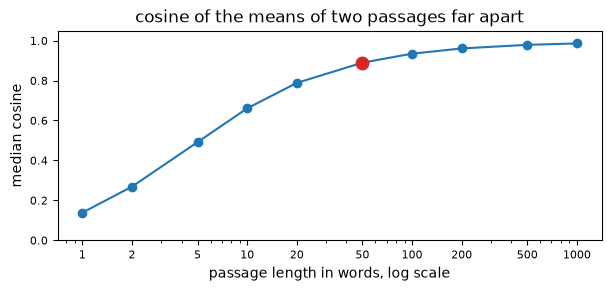

In [2]:
LENGTH = 50
passages(LENGTH)

### Solution

In [3]:
cos = {L: mean_cosine(L)[0] for L in (5, 50, 500)}
display(Markdown(f"Two passages of 5 words give means with a median cosine of {cos[5]:.3f}, of 50 words {cos[50]:.3f}, of 500 words "
                 f"{cos[500]:.3f}. The longer the passage, the more its mean looks like every other passage's mean: one vector "
                 "of fixed size keeps less of what tells one passage from another."))

Two passages of 5 words give means with a median cosine of 0.492, of 50 words 0.890, of 500 words 0.979. The longer the passage, the more its mean looks like every other passage's mean: one vector of fixed size keeps less of what tells one passage from another.

## 2. Softmax weights over the first sentence

A query word scores each word of the novel's first sentence by the cosine of
their vectors, multiplied by `SCALE`, and the softmax turns the scores into
weights. Run the cell for `husband`: which words take the most weight? Then
set `SCALE` to 0, and `QUERY` to `money`.

husband: single 0.377, wife 0.193, man 0.164; every word gets at least 0.005


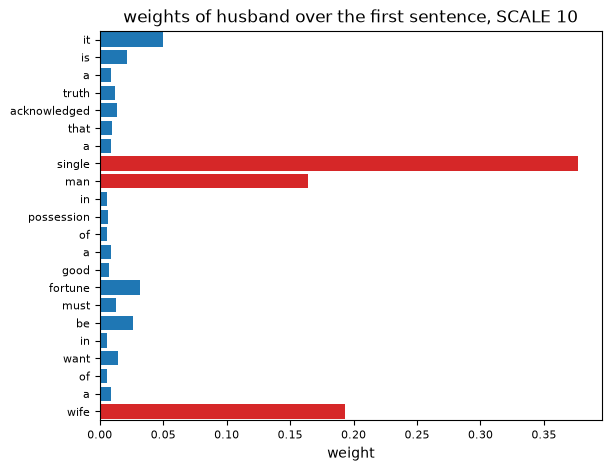

In [4]:
QUERY, SCALE = "husband", 10
attend(QUERY, SCALE)

### Solution

In [5]:
h, zero, money = weights_of("husband", 10), weights_of("husband", 0), weights_of("money", 10)
top = lambda w: ", ".join(f"`{SENTENCE[j]}` {w[j]:.3f}" for j in np.argsort(-w, kind="stable")[:3])  # noqa: E731
display(Markdown(f"`husband` puts the most weight on {top(h)}. At `SCALE` 0 every word gets {zero[0]:.3f}, one over "
                 f"{len(SENTENCE)}: equal weights, the mean of step 1. `money` puts the most on {top(money)}."))

`husband` puts the most weight on `single` 0.377, `wife` 0.193, `man` 0.164. At `SCALE` 0 every word gets 0.045, one over 22: equal weights, the mean of step 1. `money` puts the most on `want` 0.266, `fortune` 0.258, `truth` 0.147.

## 3. The sentence attending to itself

In self-attention every word of the sentence is the query once, and scores
every word, itself included; a word used twice, such as `in`, shares its
weight between its two places. Run the cell: how much weight does a word keep
on itself? Then set `SCALE` to 3.

SCALE 10: a word keeps on average 0.992 of its weight on itself and its repeats; the largest weight on a different word is 0.013, from that to it


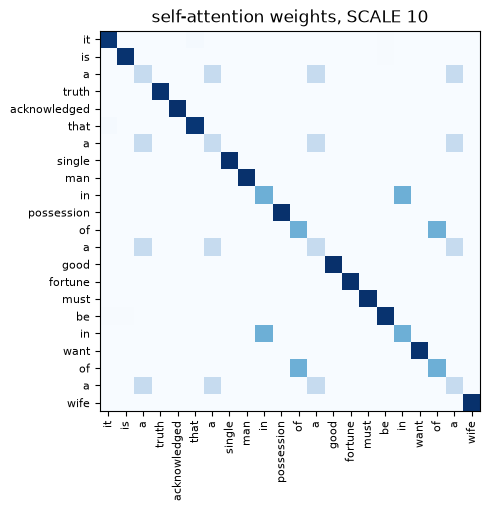

In [6]:
SCALE = 10
self_attend(SCALE)

### Solution

In [7]:
k10, k3 = kept(10), kept(3)
display(Markdown(f"At `SCALE` 10 a word keeps on average {k10[1]:.3f} of its weight on itself and its repeats, at 3 {k3[1]:.3f}: "
                 f"a vector's cosine with itself is 1, higher than with any other word. The largest weight on a different word is "
                 f"{k10[2]:.3f} at 10 and {k3[2]:.3f} at 3. A Transformer learns separate query and key vectors for each word, so "
                 "a word can weight the others more than itself."))

At `SCALE` 10 a word keeps on average 0.992 of its weight on itself and its repeats, at 3 0.456: a vector's cosine with itself is 1, higher than with any other word. The largest weight on a different word is 0.013 at 10 and 0.084 at 3. A Transformer learns separate query and key vectors for each word, so a word can weight the others more than itself.

## Appendix. One score matrix per chapter

The formulas behind the three steps:

cosine of two means = their dot product, divided by the product of their lengths

weight of a word = e to the power SCALE × cosine, divided by the same over every word of the sentence

Self-attention over T tokens stores one score for every pair of tokens, T × T
numbers of 4 bytes each, for each head of each layer. GPT-2 small reads at
most `1024` tokens at once. The chart marks the chapters that fit in that
context.

4 of 61 chapters fit in 1,024 tokens; the longest, 5,188 tokens, needs a score matrix of 108 MB, and the whole novel, 122,174 tokens, 59.7 GB


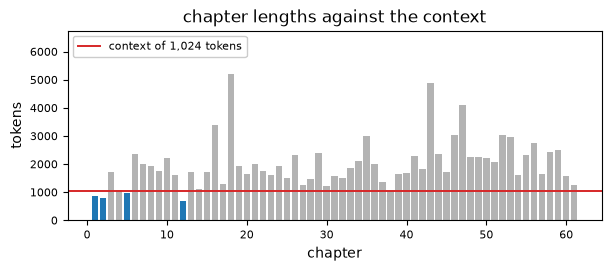

In [8]:
memory(1024)

**Exercise.** Set `CONTEXT` to `4096` and rerun the cell. How many chapters
fit now, and how many megabytes does the score matrix of the longest chapter
take?

4 of 61 chapters fit in 1,024 tokens; the longest, 5,188 tokens, needs a score matrix of 108 MB, and the whole novel, 122,174 tokens, 59.7 GB


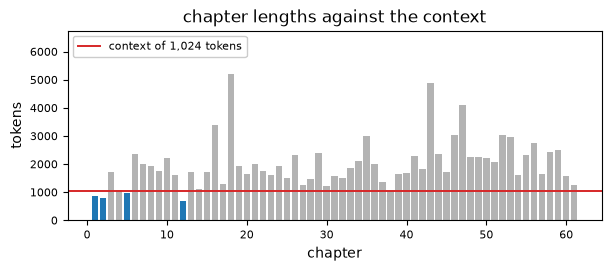

In [9]:
CONTEXT = 1024
memory(CONTEXT)

### Solution

In [10]:
lengths = np.array([len(c) for c in CHAPTERS])
display(Markdown(f"At 1024 tokens {np.sum(lengths <= 1024)} of {len(lengths)} chapters fit, at 4096 {np.sum(lengths <= 4096)}. "
                 f"The longest chapter, {lengths.max():,} tokens, needs {lengths.max() ** 2 * 4 / 1e6:.0f} MB for one score matrix, "
                 f"and the whole novel {len(tokens) ** 2 * 4 / 1e9:.1f} GB."))

At 1024 tokens 4 of 61 chapters fit, at 4096 58. The longest chapter, 5,188 tokens, needs 108 MB for one score matrix, and the whole novel 59.7 GB.